## Objective

This notebook covers Sprint 2 tasks:
- **Task 5:** Data preprocessing — feature selection and normalization
- **Task 6:** Define the optimal number of clusters (Elbow Method + Silhouette Score)
- **Task 7:** Train the K-Means model and assign clusters
- **Task 8:** Interpret and name the identified profiles

## 1. Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

SEED = 42
np.random.seed(SEED)

DATA_DIR = "../data"
SYNTHETIC_PATH = os.path.join(DATA_DIR, "synthetic_dataset.csv")
REAL_DATA_PATH = os.path.join(DATA_DIR, "real_data.csv")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10,5)

print("Setup complete.")

Setup complete.


## 2. Load Dataset

In [2]:
USE_REAL_DATA = os.path.exists(REAL_DATA_PATH)

if USE_REAL_DATA:
    df = pd.read_csv(REAL_DATA_PATH)
    print(f"Real dataset loaded: {df.shape[0]} students, {df.shape[1]} columns")
else:
    df = pd.read_csv(SYNTHETIC_PATH)
    print(f"Synthetic dataset loaded: {df.shape[0]} students, {df.shape[1]} columns")

df.head()

Synthetic dataset loaded: 120 students, 10 columns


,student_name,linguistic_score,logical_math_score,spatial_score,bodily_kinesthetic_score,interpersonal_score,intrapersonal_score,emotional_regulation,engagement_frequency,generated_archetype
0,Brenda Alves,7.9,6.7,6.7,5.8,8.7,7.2,7.0,8.3,communicative
1,Sra. Isabelly Câmara,5.9,6.7,6.7,6.4,6.9,7.3,8.5,7.1,balanced
2,Cauã Rocha,7.2,6.9,5.5,7.0,7.0,9.0,6.8,7.2,balanced
3,Dra. Aurora Pastor,5.5,4.6,7.9,9.1,7.6,6.3,6.6,7.4,kinesthetic
4,Ana Beatriz Alves,7.5,10.0,7.7,5.0,5.6,6.6,5.8,7.1,analytical


## 3. Preprocessing

### 3.1 Feature Selection

Two columns are excluded from the model:
- `student_name` - identifier, not a feature
- `generated_archetype` - generation artifact, must not be used as model input

The original scores are kept in `df` for cluster interpretation later.

In [4]:
score_columns = [
    "linguistic_score",
    "logical_math_score",
    "spatial_score",
    "bodily_kinesthetic_score",
    "interpersonal_score",
    "intrapersonal_score",
    "emotional_regulation",
    "engagement_frequency"
]

X = df[score_columns].copy()

print(f"Features selected: {len(score_columns)}")
print(f"Dataset shape for modeling: {X.shape}")

Features selected: 8
Dataset shape for modeling: (120, 8)


### 3.2 Missing Value Treatment

Missing values in score columns are filled with the column mean.
This ensures the dataset remains complete without removing student records.

> **Note:** This treatment was already applied during the exploratory analysis
> in `01_exploratory_analysis.ipynb`. It is intentionally repeated here because
> both notebooks are independent - if this notebook is executed directly with
> real data, without running the EDA first, the treatment must still be guaranteed
> before the model receives the data.

In [5]:
X = X.fillna(X.mean())

print("Missing values after treatment:")
print(X.isnull().sum())

Missing values after treatment:
linguistic_score            0
logical_math_score          0
spatial_score               0
bodily_kinesthetic_score    0
interpersonal_score         0
intrapersonal_score         0
emotional_regulation        0
engagement_frequency        0
dtype: int64


### 3.3 Normalization - StandardScaler

K-Means is sensitive to the scale of variables - it uses Euclidean distance to assign points to clusters.  
Even though all variables are already on a 0-10 scale, StandardScaler is applied to ensure equal weight across dimensions and improve cluster separation.

StandardScaler transforms each variable to have **mean = 0** and **standard deviation = 1**.

> The original scores in `df` are preserved for cluster interpretation - only `X_scaled` is used for modeling.

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for readability
X_scaled = pd.DataFrame(X_scaled, columns=score_columns)

print("Scaled dataset - summary statistics:")
X_scaled.describe().round(2)

Scaled dataset - summary statistics:


,linguistic_score,logical_math_score,spatial_score,bodily_kinesthetic_score,interpersonal_score,intrapersonal_score,emotional_regulation,engagement_frequency
count,120.00,120.00,120.00,120.00,120.00,120.00,120.00,120.00
mean,-0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.66,-2.43,-2.48,-2.38,-2.89,-2.61,-2.75,-1.75
25%,-0.72,-0.68,-0.69,-0.66,-0.77,-0.78,-0.66,-0.84
50%,0.04,-0.00,-0.09,0.00,0.08,0.01,0.12,-0.10
75%,0.62,0.70,0.69,0.53,0.68,0.66,0.70,0.74
max,2.48,2.19,2.48,2.38,2.54,3.79,2.27,2.18


## 4. Defining the Number of Clusters

### 4.1 Elbow Method

The Elbow Method evaluates the **inertia** (sum of squared distances from each point to its cluster centroid) for different values of k.  
The optimal k is where the inertia starts to decrease more slowly - the "elbow" of the curve.

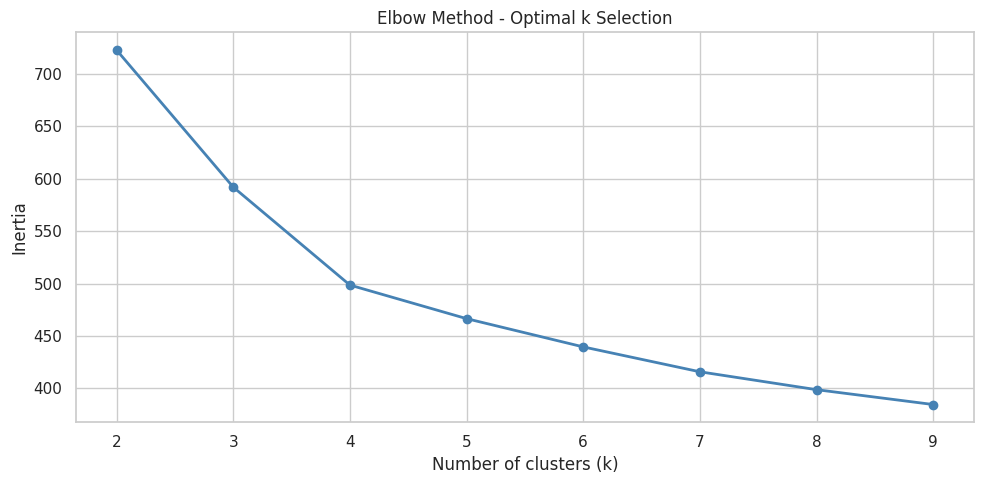

Plot saved to data/elbow_method.png


In [7]:
inertias = []
k_range = range(2,10)

for k in k_range:
  kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=10)
  kmeans.fit(X_scaled)
  inertias.append(kmeans.inertia_)
  
plt.figure(figsize=(10,5))
plt.plot(k_range, inertias, marker='o', linewidth=2, color='steelblue')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method - Optimal k Selection")
plt.xticks(k_range)
plt.tight_layout()
plt.savefig("../data/elbow_method.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to data/elbow_method.png")

### 4.2 Silhouette Score

The Silhouette Score measures how similar a point is to its own cluster compared to other clusters.  
Values range from -1 to 1 - higher is better. A score above 0.40 indicates reasonable cluster separation.

/tmp/ipykernel_4980/3744587374.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


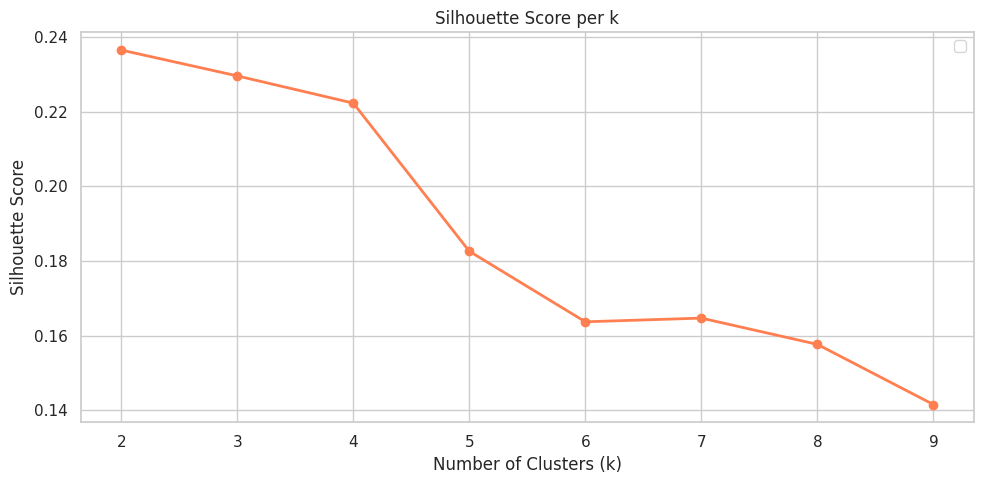

Plot saved to data/silhouette_scores.png


In [10]:
silhouette_scores = []

for k in k_range:
  kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=10)
  labels = kmeans.fit_predict(X_scaled)
  score = silhouette_score(X_scaled, labels)
  silhouette_scores.append(score)
  
plt.figure(figsize=(10, 5))
plt.plot(k_range, silhouette_scores, marker='o', linewidth=2, color='coral')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score per k")
plt.xticks(k_range)
plt.legend()
plt.tight_layout()
plt.savefig("../data/silhouette_scores.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to data/silhouette_scores.png")

### 4.3 k Selection

The Elbow Method shows a clear inflection point at **k=4** for the synthetic data, where the
rate of inertia reduction decreases significantly. Although the
Silhouette Scores remain below 0.40 across all values of k — which is
expected given the overlapping nature of synthetic profiles generated
with Gaussian noise — k=4 presents the best balance between cluster
separation (highest Silhouette Score: ~0.24) and interpretability,
aligning with the four archetypes defined in the theoretical framework.

> The low Silhouette Scores reflect the intentional similarity between
> profiles in the synthetic dataset, not a failure of the model. With real data,
> scores may vary.

> **For real data users:** Do not assume k=4. Analyze the plots above
> and update `OPTIMAL_K` based on the elbow inflection point and the
> highest Silhouette Score for your specific dataset.